# Notebook 12: Data Preparation for Fine-tuning

## Overview

- **Duration**: ~2 hours
- **Prerequisites**: Notebook 11 (Unsloth Setup)
- **Learning Objectives**:
  1. Understand different chat/instruction formats
  2. Load and explore instruction-following datasets
  3. Format data for fine-tuning
  4. Create proper train/validation splits

## Introduction

### Why Data Formatting Matters

LLMs are trained with specific conversation formats. Using the wrong format leads to:
- Poor generation quality
- Model confusion about turn boundaries
- Inability to follow instructions properly

### Common Formats

**1. Alpaca Format**
```
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{instruction}

### Response:
{response}
```

**2. ChatML Format (Qwen, many others)**
```
<|im_start|>system
{system_message}<|im_end|>
<|im_start|>user
{user_message}<|im_end|>
<|im_start|>assistant
{assistant_message}<|im_end|>
```

**3. Llama 3 Format**
```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

{system_message}<|eot_id|><|start_header_id|>user<|end_header_id|>

{user_message}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{assistant_message}<|eot_id|>
```

In [1]:
import torch
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
import json

# For visualization
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


## Step 1: Explore Available Datasets

Several popular instruction datasets are available on HuggingFace:

| Dataset | Size | Description |
|---------|------|-------------|
| `yahma/alpaca-cleaned` | 52k | Cleaned version of Stanford Alpaca |
| `databricks/dolly-15k` | 15k | Human-generated Q&A |
| `OpenAssistant/oasst1` | 161k | Multi-turn conversations |
| `HuggingFaceH4/ultrachat_200k` | 200k | Synthetic conversations |
| `teknium/OpenHermes-2.5` | 1M+ | Large mixed dataset |

In [ ]:
import os
from pathlib import Path

local_data_path = Path("/data/alpaca-cleaned")
print("cwd:", Path.cwd())
print("os.name:", os.name)
print("resolved:", local_data_path.resolve())
print("exists:", local_data_path.exists())
print("is_dir:", local_data_path.is_dir())
if local_data_path.is_dir():
    print("Cleaned dataset already found locally.")
    dataset = load_dataset("/data/alpaca-cleaned", split="train")
else:
    #from datasets import load_dataset
    print("Cleaned dataset not found locally. Saving cleaned dataset...")
    # Load Alpaca dataset (good starting point)
    dataset = load_dataset("yahma/alpaca-cleaned", split="train")
    dataset.save_to_disk(local_data_path)

print(f"Dataset size: {len(dataset):,}")
print(f"Columns: {dataset.column_names}")
print(f"\nExample:")
print(json.dumps(dataset[0], indent=2))

README.md: 0.00B [00:00, ?B/s]

c:\Users\Morit\Desktop\Projekte\DeepLearning_internship_team3\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Morit\.cache\huggingface\hub\datasets--yahma--alpaca-cleaned. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Dataset size: 51,760
Columns: ['output', 'input', 'instruction']

Example:
{
  "output": "1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.",
  "input": "",
  "instruction": "Give three tips for staying healthy."
}


In [3]:
# Explore a few more examples
print("Sample instructions:")
for i in range(5):
    print(f"\n{i+1}. {dataset[i]['instruction'][:100]}...")

Sample instructions:

1. Give three tips for staying healthy....

2. What are the three primary colors?...

3. Describe the structure of an atom....

4. How can we reduce air pollution?...

5. Pretend you are a project manager of a construction company. Describe a time when you had to make a ...


## Exercise 12.1: Create Formatting Functions (30 min)

Create functions to format examples for different model types.

In [4]:
def format_alpaca(
    instruction: str,
    input_text: str = "",
    output: str = "",
    system_prompt: str = "",
) -> str:
    """
    Format a single example in Alpaca format.
    
    Args:
        instruction: The task instruction
        input_text: Optional additional context
        output: The expected response
        system_prompt: Optional system prompt
        
    Returns:
        Formatted string
    """
    text = "Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n"
    text += f"### Instruction:\n{instruction}\n\n"
    
    if input_text and input_text.strip():
        text += f"### Input:\n{input_text}\n\n"
    
    text += f"### Response:\n{output}"
    
    return text

In [5]:
def format_chatml(
    instruction: str,
    input_text: str = "",
    output: str = "",
    system_prompt: str = "You are a helpful assistant.",
) -> str:
    """
    Format a single example in ChatML format (used by Qwen, etc.).
    
    Format:
    <|im_start|>system
    {system}<|im_end|>
    <|im_start|>user
    {user_message}<|im_end|>
    <|im_start|>assistant
    {assistant_message}<|im_end|>
    """
    """Format a single example in ChatML format."""
    # Combine instruction and input into user message
    user_message = instruction
    if input_text and input_text.strip():
        user_message = f"{instruction}\n\n{input_text}"
    
    text = f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
    text += f"<|im_start|>user\n{user_message}<|im_end|>\n"
    text += f"<|im_start|>assistant\n{output}<|im_end|>"
    
    return text

In [6]:
def format_llama3(
    instruction: str,
    input_text: str = "",
    output: str = "",
    system_prompt: str = "You are a helpful assistant.",
) -> str:
    """
    Format a single example in Llama 3 format.
    
    Format:
    <|begin_of_text|><|start_header_id|>system<|end_header_id|>
    
    {system}<|eot_id|><|start_header_id|>user<|end_header_id|>
    
    {user}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
    
    {assistant}<|eot_id|>
    """
    user_message = instruction
    if input_text and input_text.strip():
        user_message = f"{instruction}\n\n{input_text}"
    
    text = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n{system_prompt}<|eot_id|>"
    text += f"<|start_header_id|>user<|end_header_id|>\n\n{user_message}<|eot_id|>"
    text += f"<|start_header_id|>assistant<|end_header_id|>\n\n{output}<|eot_id|>"
    
    return text

In [7]:
# Test formatting functions
example = {
    "instruction": "Summarize the following text.",
    "input": "Machine learning is a subset of artificial intelligence that enables systems to learn from data.",
    "output": "ML is an AI subset where systems learn from data."
}

print("=== Alpaca Format ===")
print(format_alpaca(example["instruction"], example["input"], example["output"]))

print("\n=== ChatML Format ===")
print(format_chatml(example["instruction"], example["input"], example["output"]))

print("\n=== Llama 3 Format ===")
print(format_llama3(example["instruction"], example["input"], example["output"]))

=== Alpaca Format ===
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Summarize the following text.

### Input:
Machine learning is a subset of artificial intelligence that enables systems to learn from data.

### Response:
ML is an AI subset where systems learn from data.

=== ChatML Format ===
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Summarize the following text.

Machine learning is a subset of artificial intelligence that enables systems to learn from data.<|im_end|>
<|im_start|>assistant
ML is an AI subset where systems learn from data.<|im_end|>

=== Llama 3 Format ===
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize the following text.

Machine learning is a subset of artificial intelligence that enables systems to learn from data.<|eot_id|><|start_header_id|>assistant<|

## Exercise 12.2: Format the Dataset (20 min)

Apply formatting to the entire dataset.

In [8]:
def format_dataset(
    dataset,
    format_fn,
    instruction_col: str = "instruction",
    input_col: str = "input",
    output_col: str = "output",
) -> Dataset:
    """
    Format an entire dataset using the specified formatting function.
    
    Args:
        dataset: HuggingFace dataset
        format_fn: Formatting function (format_alpaca, format_chatml, etc.)
        instruction_col: Column name for instructions
        input_col: Column name for input context
        output_col: Column name for outputs
        
    Returns:
        Dataset with 'text' column containing formatted examples
    """
    def apply_format(example):
        formatted_text = format_fn(
            instruction=example.get(instruction_col, ""),
            input_text=example.get(input_col, ""),
            output=example.get(output_col, ""),
        )
        return {"text": formatted_text}
    
    return dataset.map(apply_format)

In [9]:
# Format dataset for Llama 3
formatted_dataset = format_dataset(dataset, format_llama3)

print(f"Formatted dataset size: {len(formatted_dataset)}")
print(f"Columns: {formatted_dataset.column_names}")
print(f"\nExample formatted text:")
print(formatted_dataset[0]['text'][:500])

Map:   0%|          | 0/51760 [00:00<?, ? examples/s]

Formatted dataset size: 51760
Columns: ['output', 'input', 'instruction', 'text']

Example formatted text:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>

Give three tips for staying healthy.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent c


## Exercise 12.3: Analyze Token Lengths (20 min)

Understanding token length distribution is important for:
- Setting `max_seq_length` appropriately
- Identifying outliers that might need filtering
- Estimating training time

In [10]:
#you need a license to access Llama-3.2-3B.
# Load tokenizer (use the same model as your fine-tuning)
#tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B") #requires permission
tokenizer = AutoTokenizer.from_pretrained("NousResearch/Llama-2-7b-hf")

# If tokenizer doesn't have a pad token, set it
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Vocab size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

c:\Users\Morit\Desktop\Projekte\DeepLearning_internship_team3\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Morit\.cache\huggingface\hub\models--NousResearch--Llama-2-7b-hf. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

Vocab size: 32,000


In [11]:
def analyze_token_lengths(dataset, tokenizer, text_column="text", sample_size=1000):
    """
    Analyze token length distribution of a dataset.
    
    Args:
        dataset: HuggingFace dataset with formatted text
        tokenizer: Tokenizer to use
        text_column: Column containing text
        sample_size: Number of examples to sample (for speed)
        
    Returns:
        List of token lengths
    """
    # Sample if needed
    if len(dataset) > sample_size:
        indices = np.random.choice(len(dataset), sample_size, replace=False)
        samples = [dataset[int(i)][text_column] for i in indices]
    else:
        samples = [dataset[i][text_column] for i in range(len(dataset))]
    
    # Tokenize and get lengths
    lengths = []
    for text in samples:
        tokens = tokenizer.encode(text)
        lengths.append(len(tokens))
    
    return lengths

In [12]:
# Analyze token lengths
lengths = analyze_token_lengths(formatted_dataset, tokenizer, sample_size=5000)

print(f"Token Length Statistics:")
print(f"  Min: {min(lengths)}")
print(f"  Max: {max(lengths)}")
print(f"  Mean: {np.mean(lengths):.1f}")
print(f"  Median: {np.median(lengths):.1f}")
print(f"  95th percentile: {np.percentile(lengths, 95):.1f}")
print(f"  99th percentile: {np.percentile(lengths, 99):.1f}")

Token Length Statistics:
  Min: 110
  Max: 979
  Mean: 283.8
  Median: 242.0
  95th percentile: 566.0
  99th percentile: 692.0


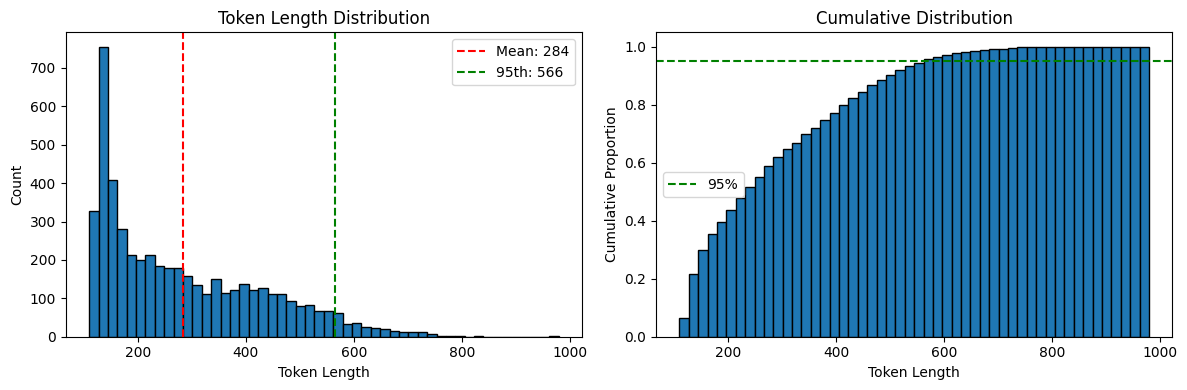

In [13]:
# Visualize distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(lengths, bins=50, edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Count')
plt.title('Token Length Distribution')
plt.axvline(x=np.mean(lengths), color='r', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
plt.axvline(x=np.percentile(lengths, 95), color='g', linestyle='--', label=f'95th: {np.percentile(lengths, 95):.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(lengths, bins=50, edgecolor='black', cumulative=True, density=True)
plt.xlabel('Token Length')
plt.ylabel('Cumulative Proportion')
plt.title('Cumulative Distribution')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.legend()

plt.tight_layout()
plt.show()

## Exercise 12.4: Filter and Split Dataset (20 min)

Filter out examples that are too long and create train/validation splits.

In [14]:
def filter_by_length(
    dataset,
    tokenizer,
    max_length: int = 2048,
    text_column: str = "text",
) -> Dataset:
    """
    Filter dataset to remove examples exceeding max_length.
    
    Args:
        dataset: HuggingFace dataset
        tokenizer: Tokenizer for length computation
        max_length: Maximum allowed token length
        text_column: Column containing text
        
    Returns:
        Filtered dataset
    """
    def is_valid_length(example):
        tokens = tokenizer.encode(example[text_column])
        return len(tokens) <= max_length
    
    return dataset.filter(is_valid_length)

In [15]:
# Filter dataset
max_length = 2048
filtered_dataset = filter_by_length(formatted_dataset, tokenizer, max_length=max_length)

print(f"Original size: {len(formatted_dataset):,}")
print(f"Filtered size: {len(filtered_dataset):,}")
print(f"Removed: {len(formatted_dataset) - len(filtered_dataset):,} examples ({(1 - len(filtered_dataset)/len(formatted_dataset))*100:.1f}%)")

Filter:   0%|          | 0/51760 [00:00<?, ? examples/s]

Original size: 51,760
Filtered size: 51,760
Removed: 0 examples (0.0%)


In [16]:
def create_train_val_split(
    dataset,
    val_size: float = 0.05,
    seed: int = 42,
):
    """
    Split dataset into training and validation sets.
    
    Args:
        dataset: HuggingFace dataset
        val_size: Fraction for validation (0.0-1.0)
        seed: Random seed for reproducibility
        
    Returns:
        Tuple of (train_dataset, val_dataset)
    """
    split = dataset.train_test_split(test_size=val_size, seed=seed)
    return split['train'], split['test']

In [17]:
# Create splits
train_dataset, val_dataset = create_train_val_split(filtered_dataset, val_size=0.05)

print(f"Training set: {len(train_dataset):,} examples")
print(f"Validation set: {len(val_dataset):,} examples")

Training set: 49,172 examples
Validation set: 2,588 examples


## Exercise 12.5: Create Dataset for Unsloth (15 min)

Unsloth/TRL expects datasets in a specific format. Let's prepare the final dataset.

In [18]:
# For Unsloth with SFTTrainer, we need a 'text' column
# Our dataset already has this from the formatting step

print("Final dataset preview:")
print(f"\nTrain columns: {train_dataset.column_names}")
print(f"Val columns: {val_dataset.column_names}")

print(f"\nSample training example:")
print(train_dataset[0]['text'][:500])

Final dataset preview:

Train columns: ['output', 'input', 'instruction', 'text']
Val columns: ['output', 'input', 'instruction', 'text']

Sample training example:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>

Name a popular author from the 21st Century.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

One popular author from the 21st Century is J.K. Rowling, known for her Harry Potter series.<|eot_id|>


In [20]:
# Optionally save to disk for later use
train_dataset.save_to_disk("data/train_dataset")
val_dataset.save_to_disk("data/val_dataset")

print("Dataset preparation complete!")
print(f"\nReady for training with:")
print(f"  - {len(train_dataset):,} training examples")
print(f"  - {len(val_dataset):,} validation examples")
print(f"  - Max sequence length: {max_length}")

Saving the dataset (0/1 shards):   0%|          | 0/49172 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2588 [00:00<?, ? examples/s]

Dataset preparation complete!

Ready for training with:
  - 49,172 training examples
  - 2,588 validation examples
  - Max sequence length: 2048


## Bonus: Custom Dataset Creation

If you have your own data, here's how to create a dataset from it:

In [21]:
# Example: Creating a dataset from a list of dictionaries
custom_data = [
    {
        "instruction": "Explain quantum computing in simple terms.",
        "input": "",
        "output": "Quantum computing uses quantum bits (qubits) that can be both 0 and 1 at the same time, allowing computers to solve certain problems much faster than traditional computers."
    },
    {
        "instruction": "Translate to German.",
        "input": "The weather is nice today.",
        "output": "Das Wetter ist heute schön."
    },
    # Add more examples...
]

# Create dataset
custom_dataset = Dataset.from_list(custom_data)
print(f"Custom dataset: {len(custom_dataset)} examples")

# Format it
custom_formatted = format_dataset(custom_dataset, format_llama3)

Custom dataset: 2 examples


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

In [21]:
# Example: Loading from a JSON file
# dataset = load_dataset('json', data_files='my_data.json')

# Example: Loading from a CSV file
# dataset = load_dataset('csv', data_files='my_data.csv')

## Summary

### What You Learned

1. **Chat Formats**: Alpaca, ChatML, Llama 3 formats
2. **Dataset Loading**: Using HuggingFace datasets
3. **Data Formatting**: Converting to model-specific formats
4. **Length Analysis**: Understanding token distributions
5. **Data Splitting**: Creating train/validation sets

### Key Points

- Always use the correct format for your model
- Filter out examples that exceed max_seq_length
- Keep ~5% for validation to monitor overfitting
- Quality data > quantity data

### Next: Fine-tuning

In Notebook 13, we'll use this prepared dataset to fine-tune our model with Unsloth!